In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [35]:
df = pd.read_csv('financial_data.csv')
print(df.shape)
df.head(10)

(9, 7)


,Company,Fiscal Year,Total Revenue,Net Income,Total Assets,Total Liabilities,CFO
0,Microsoft,2021,168088,61271,333779,191791,76740
1,Microsoft,2022,198270,72738,364840,198298,89035
2,Microsoft,2023,211915,72361,411976,205753,87582
3,Tesla,2021,53823,5644,62131,30548,11497
4,Tesla,2022,81462,12587,82338,36440,14724
5,Tesla,2023,96773,14974,106618,43009,13256
6,Apple,2021,365817,94680,351002,287912,104038
7,Apple,2022,394328,99803,352755,302083,122151
8,Apple,2023,383285,96995,352583,290437,110543


In [36]:
# Calculating Key Financial Metrics
# Revenue growth % year over year
df['Revenue Growth (%)'] = df.groupby('Company')['Total Revenue'].pct_change() * 100

# Net profit margin
df['Net Profit Margin (%)'] = (df['Net Income'] / df['Total Revenue']) * 100

# Debt to assets ratio
df['Debt-to-Assets (%)'] = (df['Total Liabilities'] / df['Total Assets']) * 100

# Round everything to 2 decimal places
df = df.round(2)

df


,Company,Fiscal Year,Total Revenue,Net Income,Total Assets,Total Liabilities,CFO,Revenue Growth (%),Net Profit Margin (%),Debt-to-Assets (%)
0,Microsoft,2021,168088,61271,333779,191791,76740,NaN,36.45,57.46
1,Microsoft,2022,198270,72738,364840,198298,89035,17.96,36.69,54.35
2,Microsoft,2023,211915,72361,411976,205753,87582,6.88,34.15,49.94
3,Tesla,2021,53823,5644,62131,30548,11497,NaN,10.49,49.17
4,Tesla,2022,81462,12587,82338,36440,14724,51.35,15.45,44.26
5,Tesla,2023,96773,14974,106618,43009,13256,18.80,15.47,40.34
6,Apple,2021,365817,94680,351002,287912,104038,NaN,25.88,82.03
7,Apple,2022,394328,99803,352755,302083,122151,7.79,25.31,85.64
8,Apple,2023,383285,96995,352583,290437,110543,-2.80,25.31,82.37


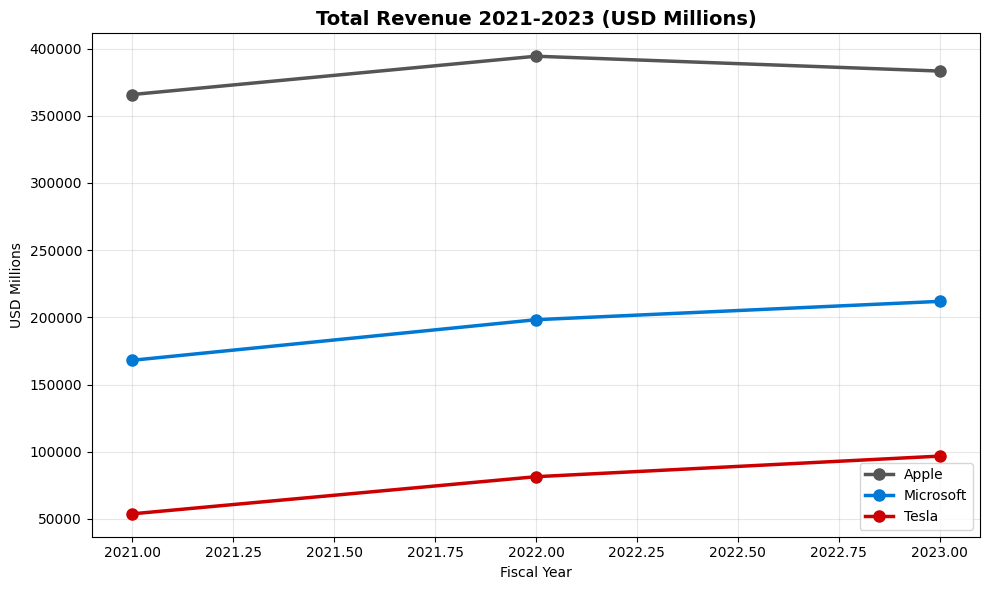

In [37]:
# Visualizations
# CHART 1: revenue Trend(2021-2023)
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Microsoft': '#0078D4', 'Tesla': '#CC0000', 'Apple': '#555555'}

for company, group in df.groupby('Company'):
    ax.plot(group['Fiscal Year'], group['Total Revenue'],
            marker='o', linewidth=2.5, markersize=8,
            label=company, color=colors[company])

ax.set_title('Total Revenue 2021-2023 (USD Millions)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('USD Millions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

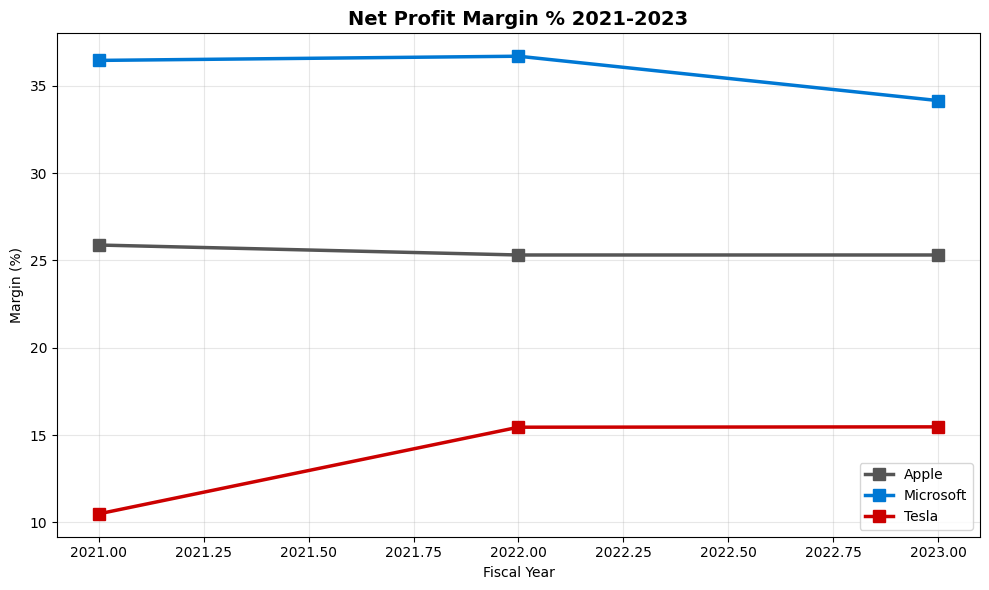

In [38]:
# CHART 2: Net Profit Margin(%)
fig, ax = plt.subplots(figsize=(10, 6))

for company, group in df.groupby('Company'):
    ax.plot(group['Fiscal Year'], group['Net Profit Margin (%)'],
            marker='s', linewidth=2.5, markersize=8,
            label=company, color=colors[company])

ax.set_title('Net Profit Margin % 2021-2023', fontsize=14, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Margin (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

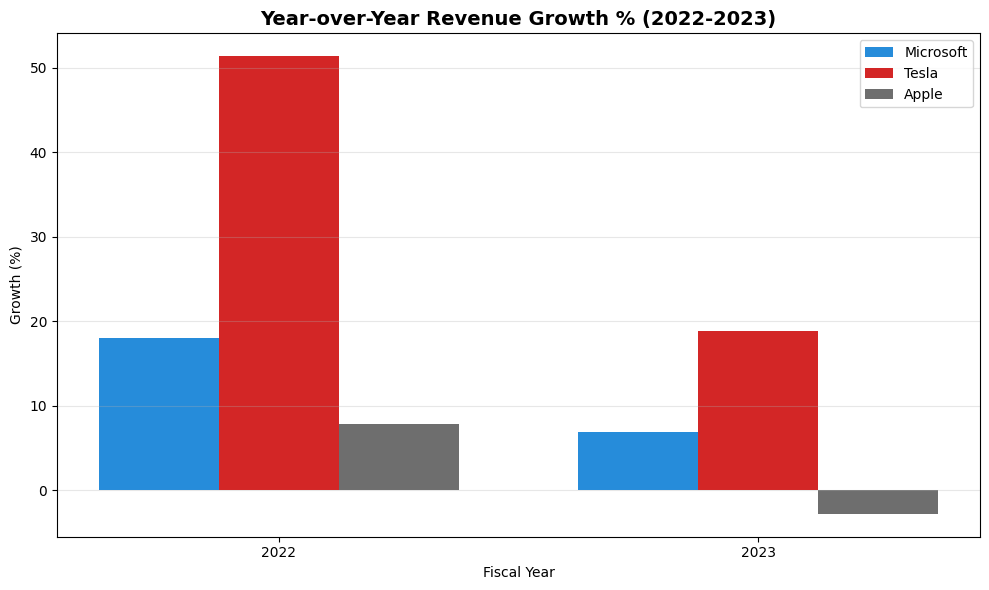

In [39]:
# CHART 3: Year-over-Year Revenue Growth Bar Chart (%)
growth_df = df.dropna(subset=['Revenue Growth (%)'])

companies = growth_df['Company'].unique()
x = growth_df['Fiscal Year'].unique()
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, company in enumerate(companies):
    company_data = growth_df[growth_df['Company'] == company]
    offset = (i - 1) * width
    ax.bar(company_data['Fiscal Year'] + offset,
           company_data['Revenue Growth (%)'],
           width=width, label=company,
           color=colors[company], alpha=0.85)

ax.set_title('Year-over-Year Revenue Growth % (2022-2023)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Growth (%)')
ax.set_xticks([2022, 2023])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

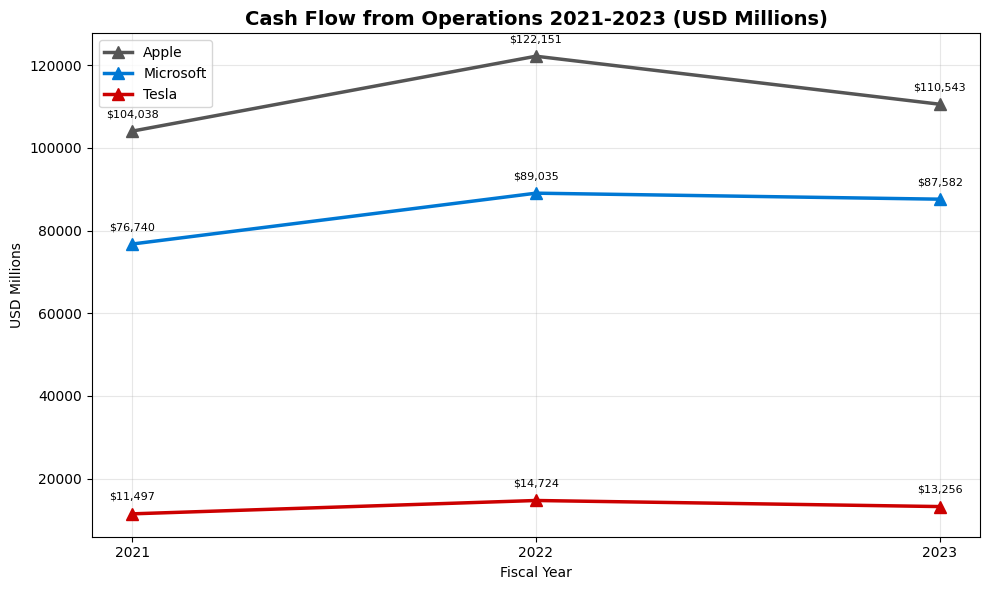

In [40]:
# CHART 4: Cash Flow from Operating Activities
fig, ax = plt.subplots(figsize=(10, 6))

for company, group in df.groupby('Company'):
    ax.plot(group['Fiscal Year'], group['CFO'],
            marker='^', linewidth=2.5, markersize=8,
            label=company, color=colors[company])
    
    # Add value labels on each data point
    for _, row in group.iterrows():
        ax.annotate(f"${row['CFO']:,.0f}",
                    (row['Fiscal Year'], row['CFO']),
                    textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=8)

ax.set_title('Cash Flow from Operations 2021-2023 (USD Millions)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('USD Millions')
ax.set_xticks([2021, 2022, 2023])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

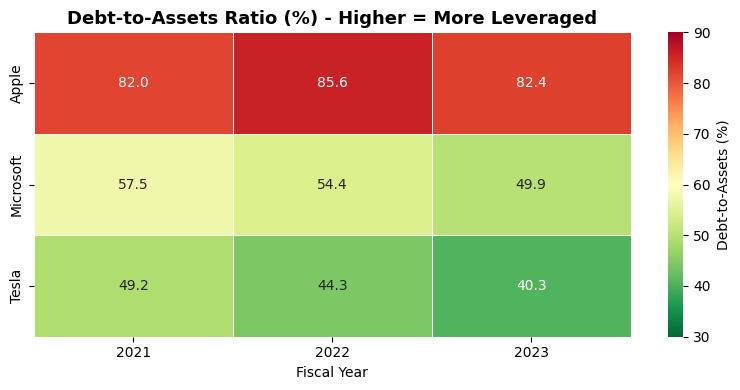

In [41]:
# CHART 5: Debt-to-Assets Ratio Heatmap
pivot = df.pivot(index='Company', 
                 columns='Fiscal Year', 
                 values='Debt-to-Assets (%)')

fig, ax = plt.subplots(figsize=(8, 4))

sns.heatmap(pivot, annot=True, fmt='.1f',
            cmap='RdYlGn_r', linewidths=0.5,
            cbar_kws={'label': 'Debt-to-Assets (%)'},
            ax=ax, vmin=30, vmax=90)

ax.set_title('Debt-to-Assets Ratio (%) - Higher = More Leveraged',
             fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [42]:
# Summary Statistics by Company
summary = df.groupby('Company').agg(
    Avg_Revenue=('Total Revenue', 'mean'),
    Avg_Net_Income=('Net Income', 'mean'),
    Avg_Margin=('Net Profit Margin (%)', 'mean'),
    Avg_CFO=('CFO', 'mean'),
    Avg_Debt_Ratio=('Debt-to-Assets (%)', 'mean')
).round(2)

print(summary.to_string())

           Avg_Revenue  Avg_Net_Income  Avg_Margin    Avg_CFO  Avg_Debt_Ratio
Company                                                                      
Apple        381143.33        97159.33       25.50  112244.00           83.35
Microsoft    192757.67        68790.00       35.76   84452.33           53.92
Tesla         77352.67        11068.33       13.80   13159.00           44.59


## Final - Written Conclusions, Key Findings & Insights

### Microsoft
- Consistent revenue growth from $168B to $212B over 3 years
- Highest net profit margin (~36%) - reflects software/cloud business model
- Declining debt-to-assets ratio shows improving financial health

### Tesla
- Fastest revenue growth in the cohort - 79% cumulative over 3 years
- Margin improving from 10% to 15% as operations scale
- Lowest leverage ratio and improving - strong financial trajectory

### Apple
- Largest company by revenue but slight contraction in FY2023 (-2.8%)
- Best absolute cash generation - over $110B operating cash flow in FY2023
- High leverage ratio (~83%) by design due to share buyback program

### Overall Conclusion
The three companies represent distinct financial profiles - Microsoft's 
high-margin software model, Tesla's high-growth scaling story, and Apple's 
mature cash-generative business. These contrasting profiles provide rich 
training data for the GFC AI chatbot's financial health assessment capability.